In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
%matplotlib inline 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df1=pd.read_csv("Algerian_dataset_cleaned_final.csv")

In [3]:
df1.drop(['Unnamed: 0'],axis=1,inplace=True)

In [5]:
#Independent and dependent features
X=df1.drop(['FWI','Classes'],axis=1)
y=df1['FWI']

In [6]:
#Train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [8]:
#Feature selection
df1.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.651400,-0.284510,-0.326492,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.516015,0.269555
RH,-0.651400,1.000000,0.244048,0.222356,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.432161,-0.402682
Ws,-0.284510,0.244048,1.000000,0.171506,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.069964,-0.181160
Rain,-0.326492,0.222356,0.171506,1.000000,-0.543906,-0.288773,-0.298023,-0.347484,-0.299852,-0.324422,-0.379097,-0.040013
FFMC,0.676568,-0.644873,-0.166548,-0.543906,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.769492,0.222241
DMC,0.485687,-0.408519,-0.000721,-0.288773,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.585658,0.192089
DC,0.376284,-0.226941,0.079135,-0.298023,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,0.511123,-0.078734
ISI,0.603871,-0.686667,0.008532,-0.347484,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.735197,0.263197
BUI,0.459789,-0.353841,0.031438,-0.299852,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.586639,0.089408
FWI,0.566670,-0.580957,0.032368,-0.324422,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.719216,0.197102


<Axes: >

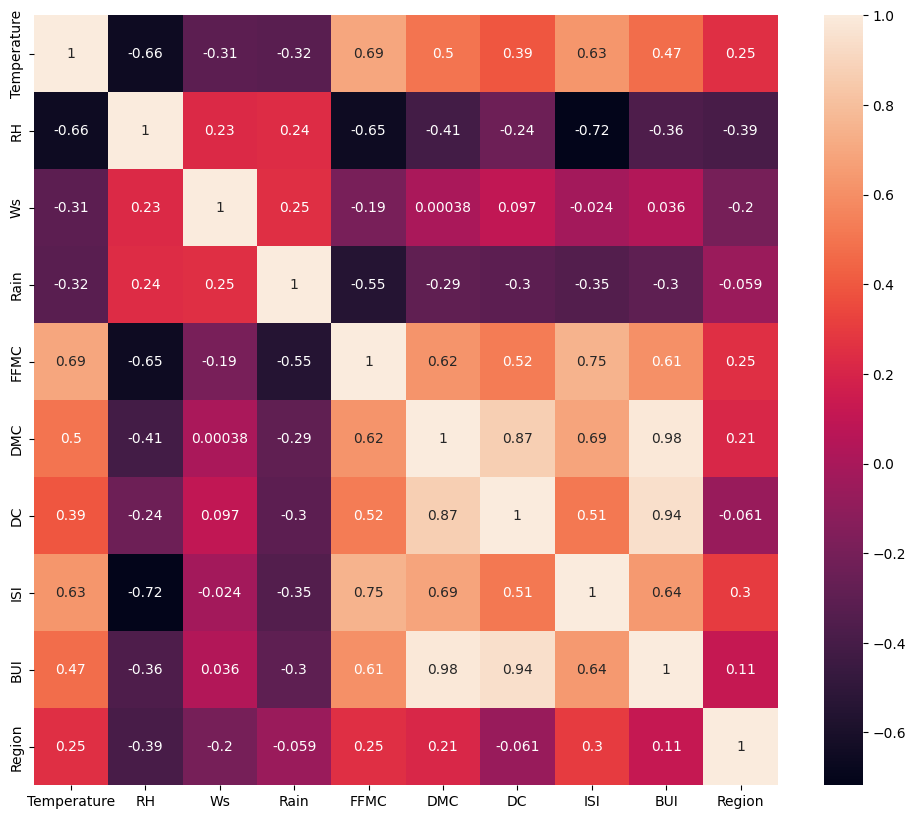

In [11]:
#Check for multicollinearity
plt.figure(figsize=(12,10))
corr=X_train.corr()
sns.heatmap(corr,annot=True)

In [12]:
#Function to remove multicollinearity
def correlation(dataset,threshold):
    col_corr=set()
    corr_matrix=dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
                colname=corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [13]:
#Threshold
c=correlation(X_train,0.85)
print(c)

{'BUI', 'DC'}


In [14]:
#Drop features with threshold with corr>0.85
X_train.drop(c,axis=1,inplace=True)
X_test.drop(c,axis=1,inplace=True)

In [15]:
X_train.shape, X_test.shape

((182, 8), (61, 8))

In [13]:
%pip install xgboost

     -------------------------------------- 101.7/101.7 MB 6.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [16]:
# ============================================
# MODEL COMPARISON FOR FWI REGRESSION
# ============================================

from sklearn.model_selection import (
    KFold,
    cross_val_score,
    RandomizedSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from xgboost import XGBRegressor



# ============================================
# 2. CROSS-VALIDATION SETUP
# ============================================

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# ============================================
# 3. STORE RESULTS
# ============================================

results = []


# ============================================
# 4. LINEAR REGRESSION
# ============================================

linear_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

linear_cv_scores = cross_val_score(
    linear_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='neg_root_mean_squared_error'
)

linear_pipeline.fit(X_train, y_train)

linear_pred = linear_pipeline.predict(X_test)

results.append({
    'Model': 'Linear Regression',
    'CV RMSE': -linear_cv_scores.mean(),
    'Test MAE': mean_absolute_error(y_test, linear_pred),
    'Test RMSE': mean_squared_error(y_test, linear_pred) ** 0.5,
    'Test R2': r2_score(y_test, linear_pred)
})


# ============================================
# 5. RIDGE REGRESSION + HYPERPARAMETER TUNING
# ============================================

ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge())
])

ridge_params = {
    'model__alpha': np.logspace(-3, 3, 30)
}

ridge_search = RandomizedSearchCV(
    ridge_pipeline,
    param_distributions=ridge_params,
    n_iter=15,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)

ridge_pred = ridge_search.predict(X_test)

results.append({
    'Model': 'Ridge',
    'CV RMSE': -ridge_search.best_score_,
    'Test MAE': mean_absolute_error(y_test, ridge_pred),
    'Test RMSE': mean_squared_error(y_test, ridge_pred) ** 0.5,
    'Test R2': r2_score(y_test, ridge_pred)
})


# ============================================
# 6. LASSO + HYPERPARAMETER TUNING
# ============================================

lasso_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(max_iter=10000))
])

lasso_params = {
    'model__alpha': np.logspace(-4, 1, 30)
}

lasso_search = RandomizedSearchCV(
    lasso_pipeline,
    param_distributions=lasso_params,
    n_iter=15,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

lasso_search.fit(X_train, y_train)

lasso_pred = lasso_search.predict(X_test)

results.append({
    'Model': 'Lasso',
    'CV RMSE': -lasso_search.best_score_,
    'Test MAE': mean_absolute_error(y_test, lasso_pred),
    'Test RMSE': mean_squared_error(y_test, lasso_pred) ** 0.5,
    'Test R2': r2_score(y_test, lasso_pred)
})


# ============================================
# 7. ELASTICNET + HYPERPARAMETER TUNING
# ============================================

elastic_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', ElasticNet(max_iter=10000))
])

elastic_params = {
    'model__alpha': np.logspace(-4, 1, 30),
    'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_search = RandomizedSearchCV(
    elastic_pipeline,
    param_distributions=elastic_params,
    n_iter=20,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

elastic_search.fit(X_train, y_train)

elastic_pred = elastic_search.predict(X_test)

results.append({
    'Model': 'ElasticNet',
    'CV RMSE': -elastic_search.best_score_,
    'Test MAE': mean_absolute_error(y_test, elastic_pred),
    'Test RMSE': mean_squared_error(y_test, elastic_pred) ** 0.5,
    'Test R2': r2_score(y_test, elastic_pred)
})


# ============================================
# 8. RANDOM FOREST + HYPERPARAMETER TUNING
# ============================================

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': [1.0, 'sqrt', 'log2']
}

rf_search = RandomizedSearchCV(
    rf,
    param_distributions=rf_params,
    n_iter=25,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

rf_pred = rf_search.predict(X_test)

results.append({
    'Model': 'Random Forest',
    'CV RMSE': -rf_search.best_score_,
    'Test MAE': mean_absolute_error(y_test, rf_pred),
    'Test RMSE': mean_squared_error(y_test, rf_pred) ** 0.5,
    'Test R2': r2_score(y_test, rf_pred)
})


# ============================================
# 9. XGBOOST + HYPERPARAMETER TUNING
# ============================================

xgb = XGBRegressor(
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_params = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [2, 3, 4, 5, 6, 8],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_search = RandomizedSearchCV(
    xgb,
    param_distributions=xgb_params,
    n_iter=25,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

xgb_pred = xgb_search.predict(X_test)

results.append({
    'Model': 'XGBoost',
    'CV RMSE': -xgb_search.best_score_,
    'Test MAE': mean_absolute_error(y_test, xgb_pred),
    'Test RMSE': mean_squared_error(y_test, xgb_pred) ** 0.5,
    'Test R2': r2_score(y_test, xgb_pred)
})


# ============================================
# 10. FINAL COMPARISON TABLE
# ============================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by='CV RMSE',
    ascending=True
).reset_index(drop=True)

print("\nMODEL COMPARISON")
print("=" * 80)

display(results_df.round(4))


# ============================================
# 11. BEST MODEL
# ============================================

best_model_name = results_df.iloc[0]['Model']

print("\n🏆 BEST MODEL BASED ON CROSS-VALIDATED RMSE:")
print(best_model_name)

KeyboardInterrupt: 

In [15]:
print("Ridge:", ridge_search.best_params_)
print("Lasso:", lasso_search.best_params_)
print("ElasticNet:", elastic_search.best_params_)
print("Random Forest:", rf_search.best_params_)
print("XGBoost:", xgb_search.best_params_)

Ridge: {'model__alpha': 0.001}
Lasso: {'model__alpha': 0.011721022975334805}
ElasticNet: {'model__l1_ratio': 0.9, 'model__alpha': 0.011721022975334805}
Random Forest: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': 10}
XGBoost: {'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 2, 'learning_rate': 0.1, 'colsample_bytree': 0.9}


In [17]:
# XGBoost metrics
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = mean_squared_error(y_test, xgb_pred) ** 0.5
xgb_r2 = r2_score(y_test, xgb_pred)

# Linear Regression metrics
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = mean_squared_error(y_test, linear_pred) ** 0.5
linear_r2 = r2_score(y_test, linear_pred)

print("XGBoost")
print("CV RMSE:", -xgb_search.best_score_)
print("Test RMSE:", xgb_rmse)
print("Test MAE:", xgb_mae)
print("Test R²:", xgb_r2)

print("\nLinear Regression")
print("Test RMSE:", linear_rmse)
print("Test MAE:", linear_mae)
print("Test R²:", linear_r2)

NameError: name 'xgb_pred' is not defined

In [19]:
from sklearn.model_selection import RepeatedKFold, cross_val_score

repeated_cv = RepeatedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=42
)

In [21]:
models_to_compare = {
    "Linear Regression": linear_pipeline,
    "Ridge": ridge_search.best_estimator_,
    "XGBoost": xgb_search.best_estimator_
}

for name, model in models_to_compare.items():

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=repeated_cv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1
    )

    rmse_scores = -scores

    print("\n", name)
    print("Mean CV RMSE:", rmse_scores.mean())
    print("Std CV RMSE:", rmse_scores.std())
    print("Best CV RMSE:", rmse_scores.min())


 Linear Regression
Mean CV RMSE: 1.352189017465082
Std CV RMSE: 0.6467721828371547
Best CV RMSE: 0.638660144219872

 Ridge
Mean CV RMSE: 1.352194348796267
Std CV RMSE: 0.6467411938698141
Best CV RMSE: 0.6386856242774052

 XGBoost
Mean CV RMSE: 1.160373220052004
Std CV RMSE: 0.287939786599261
Best CV RMSE: 0.7058652546561041


In [18]:
from xgboost import XGBRegressor

# Final XGBoost model using the best hyperparameters
final_xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=500,
    max_depth=2,
    learning_rate=0.1,
    subsample=0.7,
    colsample_bytree=0.9,
    min_child_weight=3,
    random_state=42,
    n_jobs=-1
)

# Train on training data
final_xgb.fit(X_train, y_train)

# Predict on untouched test set
final_pred = final_xgb.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

final_mae = mean_absolute_error(y_test, final_pred)
final_rmse = mean_squared_error(y_test, final_pred) ** 0.5
final_r2 = r2_score(y_test, final_pred)

print("FINAL XGBOOST MODEL")
print("=" * 40)
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

FINAL XGBOOST MODEL
MAE : 0.6409133229038266
RMSE: 0.9535923329217693
R²  : 0.9794548760916818


In [20]:
import pickle
pickle.dump(final_xgb,open('xgb.pkl','wb'))